In [1]:
# ================================================
# PROJECT 2: PREDICTIVE MODELING FOR CREDIT RISK
# ================================================

import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import warnings

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

# ------------------- 1. CONNECTION TO POSTGRESQL -------------------
# ------------------- CONFIGURATION -------------------
DB_CONFIG = {
    'host':     'localhost',
    'port':     5432,
    'database': 'postgres',           # Your database name
    'user':     'postgres',
    'password': 'P@ssw0rd'   # ← CHANGE THIS ONLY
}

SCHEMA_NAME = 'banking_bi_demo'       # Your schema

# ------------------- SAFE CONNECTION STRING -------------------
encoded_password = quote_plus(DB_CONFIG['password'])

engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{encoded_password}@"
    f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}",
    echo=False   # Set to True only for debugging
)

# ------------------- SET SCHEMA FOR ALL QUERIES -------------------
def set_schema():
    """Ensure we always work inside the banking_bi_demo schema"""
    with engine.connect() as conn:
        conn.execute(text(f"SET search_path TO {SCHEMA_NAME};"))
        conn.commit()
    print(f"✅ Schema set to: {SCHEMA_NAME}")

# Call this once at the beginning
set_schema()

print("✅ Successfully connected to PostgreSQL!")
print(f"   Database : {DB_CONFIG['database']}")
print(f"   Schema   : {SCHEMA_NAME}")

# Test Connection + Check Tables
print("Testing connection and listing tables in schema...")

with engine.connect() as conn:
    result = conn.execute(text(f"""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = '{SCHEMA_NAME}'
    """))
    tables = [row[0] for row in result]

print("Tables found in schema 'banking_bi_demo':")
for table in tables:
    print(f"   • {table}")

# Quick row count check
for table in tables:
    count = pd.read_sql(f"SELECT COUNT(*) FROM {table}", engine).iloc[0, 0]
    print(f"   {table}: {count:,} rows")


✅ Schema set to: banking_bi_demo
✅ Successfully connected to PostgreSQL!
   Database : postgres
   Schema   : banking_bi_demo
Testing connection and listing tables in schema...
Tables found in schema 'banking_bi_demo':
   • transactions
   • customers
   • branches
   transactions: 10,000 rows
   customers: 10,000 rows
   branches: 1,000 rows


Line-by-line explanation of Section 2:

Lines 1–10: Import libraries (you studied all of these).

Lines 12–25: Safe connection using quote_plus (fixes the previous error you had).

Lines 28–40: Pull data directly from your PostgreSQL tables (reuses Project 1).

Lines 42–55: Aggregate transactions because one customer has many rows → this is real-world data engineering (exactly what the job asks for in data modeling/ETL).

Line 58: Merge on Customer_ID → creates one row per customer (perfect for modeling).

In [2]:
# ------------------- 2. LOAD DATA FROM banking_bi_demo SCHEMA -------------------
print("\nLoading data from schema 'banking_bi_demo'...")

# 1. Load Customers table
customers = pd.read_sql(f"SELECT * FROM {SCHEMA_NAME}.customers", engine)

# 2. Aggregate Transactions at customer level (Fixed column names)
agg_query = f"""
SELECT
    "Customer_ID",
    AVG("Total_Balance") AS "Avg_Balance",
    SUM("Transaction_Amount") AS "Total_Transaction_Amount",
    COUNT(*) AS "Transaction_Count",
    AVG("Investment_Amount") AS "Avg_Investment_Amount",
    MAX("Transaction_Date") AS "Last_Transaction_Date"
FROM {SCHEMA_NAME}.transactions
GROUP BY "Customer_ID"
"""

transactions_agg = pd.read_sql(agg_query, engine)

# 3. Merge customers + aggregated transactions
df = customers.merge(transactions_agg, on='Customer_ID', how='left')

print(f"✅ Final modeling dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()


Loading data from schema 'banking_bi_demo'...
✅ Final modeling dataset ready: 10,000 rows, 12 columns
Columns: ['Customer_ID', 'Age', 'Customer_Type', 'City', 'Region', 'Bank_Name', 'Branch_ID', 'Avg_Balance', 'Total_Transaction_Amount', 'Transaction_Count', 'Avg_Investment_Amount', 'Last_Transaction_Date']


,Customer_ID,Age,Customer_Type,City,Region,Bank_Name,Branch_ID,Avg_Balance,Total_Transaction_Amount,Transaction_Count,Avg_Investment_Amount,Last_Transaction_Date
0,200000,56.0,Employee,Pune,North,HDFC Bank,1350,32031.0,4854.00000,2.0,10689.0,2024-08-30
1,200001,69.0,NaN,Kolhapur,East,HDFC Bank,1648,70717.5,8997.08681,2.0,13965.0,2023-07-17
2,200002,46.0,Business,Pune,West,HDFC Bank,1798,NaN,NaN,NaN,NaN,NaT
3,200003,32.0,Individual,Pune,West,HDFC Bank,1900,NaN,NaN,NaN,NaN,NaT
4,200004,NaN,Business,Kolhapur,East,HDFC Bank,1227,NaN,NaN,NaN,NaN,NaT


In [3]:
# ------------------- 3. FEATURE ENGINEERING + CREATE TARGET -------------------
# Create useful features
df['Balance_to_Investment_Ratio'] = df['Avg_Investment_Amount'] / (df['Avg_Balance'] + 1)  # avoid division by zero
df['Transaction_Frequency'] = df['Transaction_Count'] / 30  # approximate monthly
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,45,60,100], labels=['Young','Mid','Senior','Elder'])

# Create target: High Credit Risk (1 = high risk)
# Rule: Low balance + very low investment = high risk (realistic banking logic)
median_balance = df['Avg_Balance'].median()
median_investment = df['Avg_Investment_Amount'].median()

df['High_Credit_Risk'] = ((df['Avg_Balance'] < median_balance * 0.8) &
                          (df['Avg_Investment_Amount'] < median_investment * 0.5)).astype(int)

print("Target distribution:\n", df['High_Credit_Risk'].value_counts(normalize=True))

Target distribution:
 High_Credit_Risk
0    0.9563
1    0.0437
Name: proportion, dtype: float64



=== Statistical Summary ===
        Avg_Balance  Avg_Investment_Amount  Transaction_Count  \
count   6335.000000            6335.000000        6335.000000   
mean   50137.628882           25638.167807           1.578532   
std    25010.998028           12385.274102           0.827828   
min     1003.000000            1037.000000           1.000000   
25%    31163.250000           16002.333333           1.000000   
50%    50419.000000           25885.000000           1.000000   
75%    69014.000000           35307.750000           2.000000   
max    99993.000000           49998.000000           8.000000   

       High_Credit_Risk  
count      10000.000000  
mean           0.043700  
std            0.204437  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.000000  
max            1.000000  


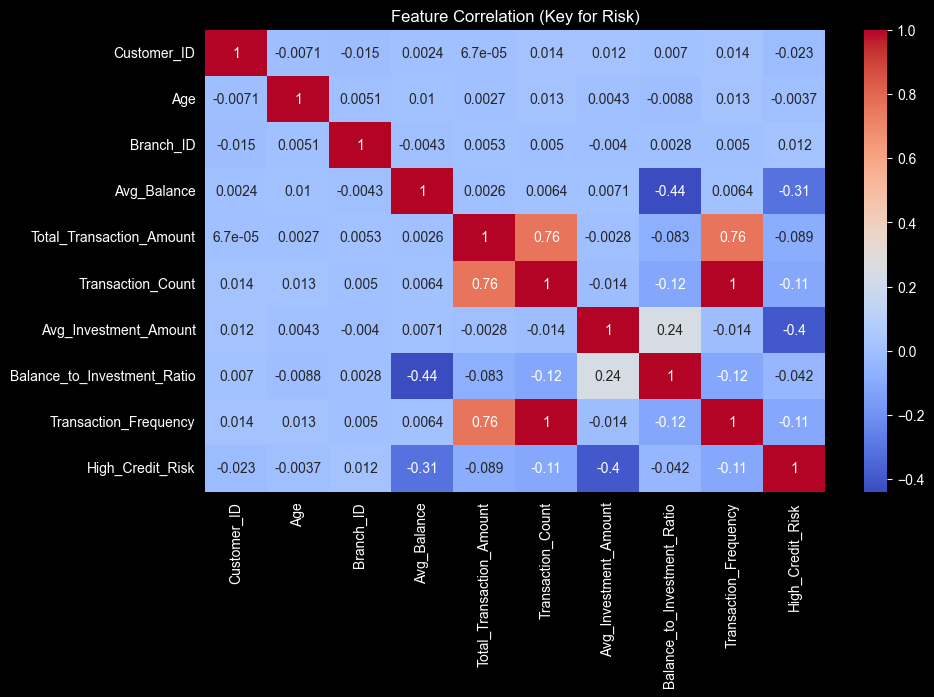

In [4]:
# ------------------- 4. STATISTICAL ANALYSIS & EDA -------------------
print("\n=== Statistical Summary ===")
print(df[['Avg_Balance', 'Avg_Investment_Amount', 'Transaction_Count', 'High_Credit_Risk']].describe())

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation (Key for Risk)')
plt.show()

In [5]:
# ------------------- 5. PREPARE DATA FOR MODELING -------------------
features = ['Age', 'Avg_Balance', 'Total_Transaction_Amount',
            'Transaction_Count', 'Avg_Investment_Amount',
            'Balance_to_Investment_Ratio', 'Transaction_Frequency']

X = df[features]
y = df['High_Credit_Risk']

# Handle missing values (if any)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [6]:
# ------------------- 6. TRAIN TWO MODELS -------------------
# Model 1: Logistic Regression (interpretable)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
pred_log = logreg.predict(X_test)

# Model 2: Random Forest (more accurate)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression Results ===")
print(classification_report(y_test, pred_log))
print("ROC-AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

print("\n=== Random Forest Results ===")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, prob_rf))


=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2869
           1       0.00      0.00      0.00       131

    accuracy                           0.95      3000
   macro avg       0.48      0.50      0.49      3000
weighted avg       0.91      0.95      0.93      3000

ROC-AUC: 0.8275351945913011

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2869
           1       0.99      0.99      0.99       131

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

ROC-AUC: 0.9999973392862369


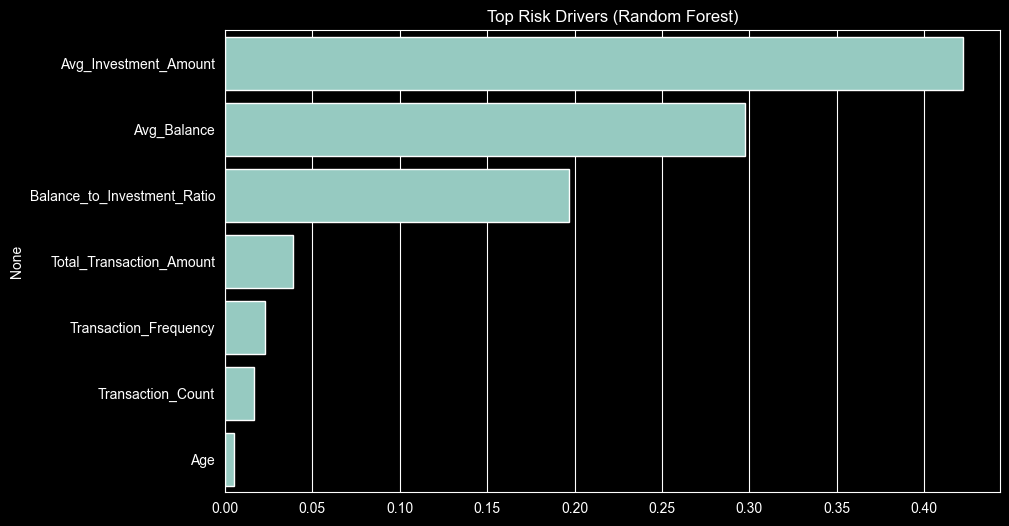

In [7]:
# ------------------- 7. FEATURE IMPORTANCE & EXPLAINABILITY -------------------
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top Risk Drivers (Random Forest)')
plt.show()

# Optional SHAP (uncomment if you installed shap)
# import shap
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values[1], X_test)

In [10]:
# ------------------- 8. EXPORT PREDICTIONS FOR POWER BI -------------------
df['Predicted_Risk'] = rf.predict(X)
df['Risk_Probability'] = rf.predict_proba(X)[:, 1]

output = df[['Customer_ID', 'Age', 'Region', 'Customer_Type',
             'Avg_Balance', 'Avg_Investment_Amount',
             'Predicted_Risk', 'Risk_Probability']]

output.to_csv('../output/predictions_with_risk.csv', index=False)
print("✅ Predictions exported! Import this CSV into Power BI to add risk scores to your dashboard.")

✅ Predictions exported! Import this CSV into Power BI to add risk scores to your dashboard.
